## Задание 3
*Используйте любой набор данных на ваше усмотрение. Выберите модель
машинного обучения и метод-обертку для отбора признаков. Примените кросс-
валидацию, чтобы оценить эффективность этого подхода.*

## Задание 4
*Используйте один и тот же набор данных для применения различных
методов-оберток для отбора признаков, например, RFE и Sequential Feature
Selector, и сравните полученные результаты.*

In [535]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.core.common import random_state
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### Загружаем датасет

In [536]:
monsters = pd.read_csv('cleaned_monsters_basic.csv')
monsters.describe()

,Unnamed: 0,ac,hp,strength,str_mod,dex,dex_mod,con,con_mod,intel,...,perception,stealth,persuasion,insight,deception,arcana,religion,acrobatics,athletics,intimidation
count,324.00000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,...,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000
mean,161.50000,14.043210,81.324074,15.117284,2.169753,12.651235,1.123457,15.067901,2.283951,7.799383,...,1.601852,0.685185,0.246914,0.299383,0.231481,0.259259,0.061728,0.018519,0.185185,0.015432
std,93.67497,3.245094,99.182494,6.739180,3.227045,3.210658,1.605970,4.495097,2.183442,5.715104,...,3.913001,1.920952,1.631963,1.519695,1.323331,1.667595,0.877594,0.333333,1.415186,0.277778
min,0.00000,5.000000,1.000000,1.000000,-5.000000,1.000000,-5.000000,8.000000,-1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,80.75000,12.000000,18.750000,11.000000,0.000000,10.000000,0.000000,12.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,161.50000,13.000000,45.000000,16.000000,3.000000,13.000000,1.000000,14.000000,2.000000,7.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,242.25000,17.000000,114.000000,19.000000,4.000000,15.000000,2.000000,18.000000,3.250000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,323.00000,25.000000,676.000000,30.000000,9.000000,28.000000,9.000000,30.000000,9.000000,25.000000,...,17.000000,9.000000,16.000000,10.000000,11.000000,18.000000,15.000000,6.000000,14.000000,5.000000


In [537]:
monsters.head()

,Unnamed: 0,name,size,monster_type,alignment,ac,hp,strength,str_mod,dex,...,perception,stealth,persuasion,insight,deception,arcana,religion,acrobatics,athletics,intimidation
0,0,Aboleth,Large,Aberration,lawful evil,17,135,21,5,9,...,10,0,0,0,0,0,0,0,0,0
1,1,Acolyte,Medium,Humanoid (any race),any alignment,10,9,10,0,10,...,0,0,0,0,0,0,0,0,0,0
2,2,Adult Black Dragon,Huge,Dragon,chaotic evil,19,195,23,6,14,...,11,7,0,0,0,0,0,0,0,0
3,3,Adult Blue Dragon,Huge,Dragon,lawful evil,19,225,25,7,10,...,12,5,0,0,0,0,0,0,0,0
4,4,Adult Brass Dragon,Huge,Dragon,chaotic good,18,172,23,6,10,...,11,5,8,0,0,0,0,0,0,0


### В этом датасете множество признаков. Будем пытаться классифицировать монстров из D&D по наличию или отсутствию у них особого вида передвижения (плавание, полёт, лазание, копание)

In [538]:
print(monsters.columns.values.tolist())

['Unnamed: 0', 'name', 'size', 'monster_type', 'alignment', 'ac', 'hp', 'strength', 'str_mod', 'dex', 'dex_mod', 'con', 'con_mod', 'intel', 'int_mod', 'wis', 'wis_mod', 'cha', 'cha_mod', 'senses', 'languages', 'cr', 'str_save', 'dex_save', 'con_save', 'int_save', 'wis_save', 'cha_save', 'speed', 'swim', 'fly', 'climb', 'burrow', 'number_legendary_actions', 'history', 'perception', 'stealth', 'persuasion', 'insight', 'deception', 'arcana', 'religion', 'acrobatics', 'athletics', 'intimidation']


### Очищаем датасет от всего лишнего, а также от нечисловых признаков. Заменяем значения типа "1/4" на числовые

In [539]:
monsters_cleaned = (monsters
            .copy()
            .drop(['name','Unnamed: 0', 'size', 'monster_type', 'alignment', 'languages', 'senses'], axis=1)
            .dropna(axis=0, how='any')
            .drop_duplicates()
            .replace({'cr':{'1/4': '0.25', '1/2': '0.5', '1/8': '0.125'}}))
monsters_cleaned["cr"] = pd.to_numeric(monsters_cleaned["cr"], errors='coerce')

monsters_cleaned

,ac,hp,strength,str_mod,dex,dex_mod,con,con_mod,intel,int_mod,...,perception,stealth,persuasion,insight,deception,arcana,religion,acrobatics,athletics,intimidation
0,17,135,21,5,9,-1,15,2,18,4,...,10,0,0,0,0,0,0,0,0,0
1,10,9,10,0,10,0,10,0,10,0,...,0,0,0,0,0,0,0,0,0,0
2,19,195,23,6,14,2,21,5,14,2,...,11,7,0,0,0,0,0,0,0,0
3,19,225,25,7,10,0,23,6,16,3,...,12,5,0,0,0,0,0,0,0,0
4,18,172,23,6,10,0,21,5,14,2,...,11,5,8,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,18,136,19,4,12,1,17,3,16,3,...,7,4,0,0,5,0,0,0,0,0
320,18,178,23,6,10,0,21,5,14,2,...,8,4,0,0,0,0,0,0,0,0
321,18,168,23,6,10,0,21,5,14,2,...,8,4,0,0,0,6,0,0,0,0
322,17,133,18,4,10,0,18,4,6,-2,...,6,3,0,0,0,0,0,0,0,0


### Агрегируем все четыре особых вида передвижения в один со значением 1, если хоть один из четырёх присутствует, иначе 0

In [540]:
monsters_data = monsters_cleaned.copy()
monsters_data["special_speed"] = (monsters_data[['swim', 'fly', 'climb', 'burrow']]
                                  .sum(axis=1)
                                  .apply(lambda x: 1 if x > 0 else 0))
monsters_data = monsters_data.drop(["swim", "climb", "fly", "burrow"], axis=1)
monsters_data

,ac,hp,strength,str_mod,dex,dex_mod,con,con_mod,intel,int_mod,...,stealth,persuasion,insight,deception,arcana,religion,acrobatics,athletics,intimidation,special_speed
0,17,135,21,5,9,-1,15,2,18,4,...,0,0,0,0,0,0,0,0,0,1
1,10,9,10,0,10,0,10,0,10,0,...,0,0,0,0,0,0,0,0,0,0
2,19,195,23,6,14,2,21,5,14,2,...,7,0,0,0,0,0,0,0,0,1
3,19,225,25,7,10,0,23,6,16,3,...,5,0,0,0,0,0,0,0,0,1
4,18,172,23,6,10,0,21,5,14,2,...,5,8,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,18,136,19,4,12,1,17,3,16,3,...,4,0,0,5,0,0,0,0,0,1
320,18,178,23,6,10,0,21,5,14,2,...,4,0,0,0,0,0,0,0,0,1
321,18,168,23,6,10,0,21,5,14,2,...,4,0,0,0,6,0,0,0,0,1
322,17,133,18,4,10,0,18,4,6,-2,...,3,0,0,0,0,0,0,0,0,1


In [541]:
print("Подсчёт получившихся монстров по классу наличия особого передвижения:")
monsters_data["special_speed"].value_counts()

Подсчёт получившихся монстров по классу наличия особого передвижения:


special_speed
1    173
0    146
Name: count, dtype: int64

### Применяем стандартизацию

In [542]:
from sklearn.preprocessing import StandardScaler

x_scaled = StandardScaler().fit_transform(monsters_data.drop(["special_speed"], axis=1))
y = monsters_data["special_speed"]

### **Кросс-валидация**
#### **_Кросс-валидация_** — это метод оценки производительности модели машинного обучения, который позволяет более надежно оценить её способность обобщать данные. Вместо того чтобы разделять данные только на одну обучающую и тестовую выборки, кросс-валидация использует несколько разделений данных, чтобы уменьшить влияние случайности при разделении.
#### Используется для:
* **Оценка обобщающей способности модели**:
    Кросс-валидация помогает оценить, насколько хорошо модель будет работать на новых, ранее не виденных данных.
    Это особенно важно, если размер набора данных ограничен, так как случайное разделение может привести к несбалансированным обучающим и тестовым выборкам.
* **Снижение дисперсии оценки**:
    При использовании одной обучающей и тестовой выборок результаты могут сильно зависеть от конкретного разделения данных.
    Кросс-валидация усредняет результаты по нескольким разделениям, что делает оценку более стабильной.
* **Выбор гиперпараметров**:
    Кросс-валидация часто используется для подбора гиперпараметров модели (например, с помощью GridSearchCV или RandomizedSearchCV).
* **Проверка устойчивости модели**: 
    Если модель показывает плохие результаты на некоторых фолдах (разделениях), это может указывать на проблемы, такие как переобучение или недостаток данных.

#### Для этого блока заданий мы будем использовать k-fold кросс-валидацию и метод _cross_val_score_ из библиотеки sklearn

https://www.geeksforgeeks.org/cross-validation-using-k-fold-with-scikit-learn/

### Создаём модель RandomForestClassifier и используем кросс-валидацию для подбора гиперпараметров модели. Получаем среднюю точность в 0,75 при всех признаках.

In [543]:
model = RandomForestClassifier(n_estimators=27, random_state=42, max_depth=7)
scores = cross_val_score(estimator=model, X=x_scaled, y=y, cv=5, scoring='accuracy')
print("Точность при каждом фолде:", scores.tolist())
print("Средняя точность:", scores.mean())

Точность при каждом фолде: [0.84375, 0.703125, 0.703125, 0.71875, 0.8571428571428571]
Средняя точность: 0.7651785714285715


### Создаём и используем SequentialFeatureSelector для отбора признаков, внутри используем ранее полученную модель

In [544]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=7,
    cv=5,
    n_jobs=-1)

sfs.fit(x_scaled, y)

SequentialFeatureSelector(estimator=RandomForestClassifier(max_depth=7,
                                                           n_estimators=27,
                                                           random_state=42),
                          n_features_to_select=7, n_jobs=-1)

In [545]:
feature_names = monsters_data.columns
selected_mask_sfs = sfs.get_support()
selected_features_sfs = [feature_names[i] for i in range(len(feature_names) - 1) if selected_mask_sfs[i]]
print("Выбранные с помощью SFS признаки:", selected_features_sfs)

Выбранные с помощью SFS признаки: ['strength', 'str_mod', 'dex_mod', 'int_mod', 'wis_mod', 'speed', 'perception']


### Создаём и используем RFE для отбора признаков, внутри используем ранее полученную модель

In [546]:
from sklearn.feature_selection import RFE

rfe = RFE(estimator=model, n_features_to_select=7)
rfe.fit(x_scaled, y)

RFE(estimator=RandomForestClassifier(max_depth=7, n_estimators=27,
                                     random_state=42),
    n_features_to_select=7)

In [547]:
selected_mask_rfe = rfe.get_support()
selected_features_rfe = [feature_names[i] for i in range(len(feature_names) - 1) if selected_mask_rfe[i]]
print("Выбранные с помощью RFE признаки:", selected_features_rfe)

Выбранные с помощью RFE признаки: ['ac', 'hp', 'strength', 'dex', 'intel', 'cha', 'speed']


### Как можем видеть, отобранные признаки с помощью SFS и RFE разительно отличаются. 
#### Это связано с тем, что эти два метода работают по-разному: RFE рекурсивно "устраняет" признаки на основе их важности, пока SFS, в данном случае идущий "вперёд", добавляет признаки по-одному. SFS более гибкий, однако может застрять в локальных оптимумах, в то время как RFE сильно зависит от базовой модели и может быть вычислительно затратным.

In [548]:
x_sfs = monsters_data[selected_features_sfs]
x_rfe = monsters_data[selected_features_rfe]

#### Проведём кросс-валидацию модели, используя признаки, отобранные SFS

In [549]:
scores = cross_val_score(estimator=model, X=x_sfs, y=y, cv=5, scoring='accuracy')
print("Точность при каждом фолде:", scores.tolist())
print("Средняя точность:", scores.mean())

Точность при каждом фолде: [0.875, 0.75, 0.65625, 0.734375, 0.8888888888888888]
Средняя точность: 0.7809027777777777


#### Проведём кросс-валидацию модели, используя признаки, отобранные RFE

In [550]:
scores = cross_val_score(estimator=model, X=x_rfe, y=y, cv=5, scoring='accuracy')
print("Точность при каждом фолде:", scores.tolist())
print("Средняя точность:", scores.mean())

Точность при каждом фолде: [0.8125, 0.671875, 0.640625, 0.640625, 0.7777777777777778]
Средняя точность: 0.7086805555555555


### Исходя из полученных результатов, можем сказать, что SSF лучше справился с отбором признаков для нашего Случайного Леса, имея более высокую среднюю точность по всему датасету.

### Проведём ещё немного опытов. Вместо кросс-валидации, поделим данные на обучающую и тестовую выборки, после чего обучим её сначала на признаках от SFS, после на признаках от RFE, и оценим производительности моделей.

## **SFS**

In [561]:
x_train, x_test, y_train, y_test = train_test_split(x_sfs, y, test_size=0.2, random_state=42, shuffle=True)
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=7, n_estimators=27, random_state=42)

In [562]:
y_pred = model.predict(x_test)
print("Классификация, использующая признаки SFS:")
print(classification_report(y_test, y_pred))

Классификация, использующая признаки SFS:
              precision    recall  f1-score   support

           0       0.63      0.70      0.67        27
           1       0.76      0.70      0.73        37

    accuracy                           0.70        64
   macro avg       0.70      0.70      0.70        64
weighted avg       0.71      0.70      0.70        64



Text(0.5, 1.0, 'ROC Curve')

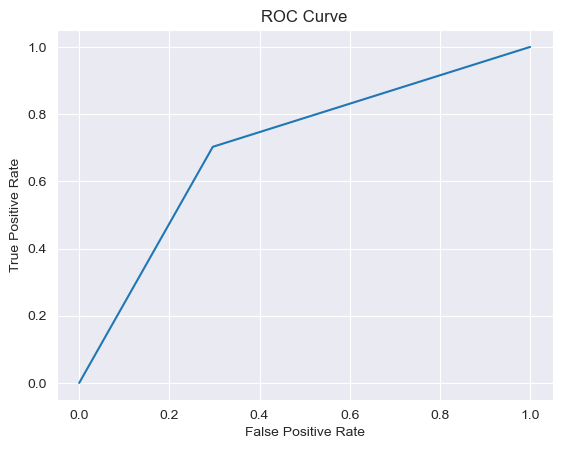

In [563]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr, label='ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

## RFE

In [564]:
x_train, x_test, y_train, y_test = train_test_split(x_rfe, y, test_size=0.2, random_state=42, shuffle=True)
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=7, n_estimators=27, random_state=42)

In [565]:
y_pred = model.predict(x_test)
print("Классификация, использующая признаки RFE:")
print(classification_report(y_test, y_pred))

Классификация, использующая признаки RFE:
              precision    recall  f1-score   support

           0       0.64      0.67      0.65        27
           1       0.75      0.73      0.74        37

    accuracy                           0.70        64
   macro avg       0.70      0.70      0.70        64
weighted avg       0.70      0.70      0.70        64



Text(0.5, 1.0, 'ROC Curve')

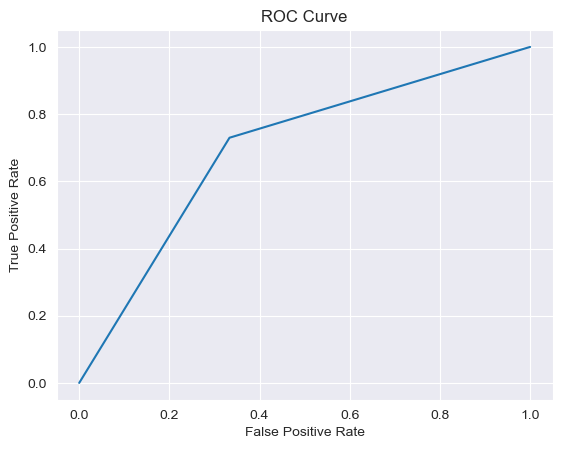

In [566]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr, label='ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

### Исходя из полученных отчётов о классификации, а также построенных ROC-кривых, можно сделать вывод, что модель с признаками от SFS действительно отрабатывает лучше модели с признаками от RFE (пускай и незначительно). Вероятно, это связано с использованием одной и той же модели для каждого опыта, а также с использованием Случайного Леса.
#### **Примечание**: ROC-кривые имеют такой вид вероятно из-за малого объёма данных.

https://habr.com/ru/companies/otus/articles/809147/

### **Итог по классификации**:
#### Определение наличия у монстра особого типа передвижения при помощи использованных моделей возможно, однако далеко от идеала